/tmp/ipykernel_157827/1589809550.py:62: RuntimeWarning: invalid value encountered in divide
  rhoC = histC / (shell_vol * nframes)
/tmp/ipykernel_157827/1589809550.py:63: RuntimeWarning: invalid value encountered in divide
  rhoD = histD / (shell_vol * nframes)


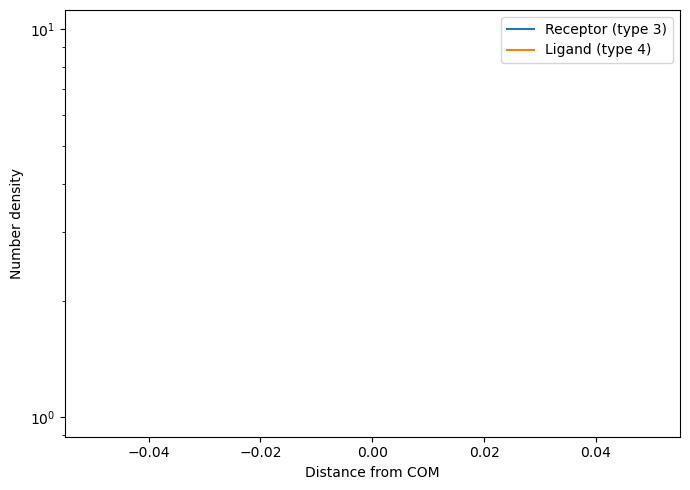

In [3]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

u = mda.Universe(
    "lammps.data",
    "traj.lammpstrj",
    format="LAMMPSDUMP"
)

dr = 0.5
rmax = 50
bins = np.arange(0, rmax + dr, dr)

histC = np.zeros(len(bins) - 1)
histD = np.zeros(len(bins) - 1)

nframes = 0

                
for ts in u.trajectory[200:400]:

                               
    C = u.select_atoms("type 3 and prop z >= 32 and prop z <= 35")
    D = u.select_atoms("type 4 and prop z >= 32 and prop z <= 35")

    if len(C) == 0 or len(D) == 0:
        continue

    comC = C.center_of_mass()
    comD = D.center_of_mass()

    dC = np.linalg.norm(
        C.positions - comC,
        axis=1
    )

    dD = np.linalg.norm(
        D.positions - comD,
        axis=1
    )

    histC += np.histogram(
        dC,
        bins=bins
    )[0]

    histD += np.histogram(
        dD,
        bins=bins
    )[0]

    nframes += 1

r = 0.5 * (bins[:-1] + bins[1:])
shell_vol = (4.0 * np.pi / 3.0) * (
    bins[1:]**3 - bins[:-1]**3
)

shell_vol = np.where(shell_vol == 0, 1e-12, shell_vol)

rhoC = histC / (shell_vol * nframes)
rhoD = histD / (shell_vol * nframes)

plt.figure(figsize=(7, 5))

plt.plot(
    r,
    rhoC,
    label="Receptor (type 3)"
)

plt.plot(
    r,
    rhoD,
    label="Ligand (type 4)"
)

plt.xlabel("Distance from COM")
plt.ylabel("Number density")
plt.yscale("log")
plt.legend()

plt.tight_layout()

plt.savefig(
    "receptor_ligand_radial_density.png",
    dpi=300
)

plt.show()

In [8]:
import MDAnalysis as mda
from collections import Counter

u = mda.Universe(
    "lammps.data",
    "traj.lammpstrj",
    topology_format="DATA",
    format="LAMMPSDUMP"
)

                     
print("Total atoms    :", len(u.atoms))

                                   
print("Residues       :", len(u.residues))

                                                 
type_counts = Counter(u.atoms.types)
print("Atom type counts:", dict(type_counts))

Total atoms    : 30200
Residues       : 1201
Atom type counts: {'1': 15000, '2': 15000, '3': 100, '4': 100}


In [5]:
                  
import numpy as np
types, counts = np.unique(u.atoms.types, return_counts=True)
for t, c in zip(types, counts):
    print(f"  type {t}: {c} atoms")

  type 1: 15000 atoms
  type 2: 15000 atoms
  type 3: 100 atoms
  type 4: 100 atoms
